In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("scanpy version:", sc.__version__)
print("All imports OK!")


scanpy version: 1.12.1
All imports OK!


/var/folders/tt/5f_2yqk97hs4jsnsbtj24bl00000gp/T/ipykernel_22902/3767437191.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy version:", sc.__version__)


In [2]:
# Load one PCOS sample (Mc03 = PCOS affected)
pcos = sc.read_10x_mtx(
    '/Users/jacob1/Desktop/biohackathon/OneDrive_1_13-05-2026/(Supplementary_Dataset)_PCOS_single_cell_data/11_4796UPenn_Mc03-C_scRNA-seq_hs_SI-GA-D3/filtered_feature_bc_matrix/',
    var_names='gene_symbols',
    cache=True
)
pcos.obs['condition'] = 'PCOS'
pcos.obs['sample'] = 'Mc03'

# Load one Normal sample (Mc02 = normal cycling woman)
normal = sc.read_10x_mtx(
    '/Users/jacob1/Desktop/biohackathon/OneDrive_1_13-05-2026/(Supplementary_Dataset)_PCOS_single_cell_data/01_4796UPenn_Mc02-C_scRNA-seq_hs_SI-GA-E1/filtered_feature_bc_matrix/',
    var_names='gene_symbols',
    cache=True
)
normal.obs['condition'] = 'Normal'
normal.obs['sample'] = 'Mc02'

print("PCOS cells:", pcos.n_obs, "| Genes:", pcos.n_vars)
print("Normal cells:", normal.n_obs, "| Genes:", normal.n_vars)

PCOS cells: 3689 | Genes: 36601
Normal cells: 3361 | Genes: 36601


In [3]:
# Merge PCOS and Normal
import anndata as ad
adata = ad.concat([pcos, normal], label='condition', keys=['PCOS', 'Normal'])
print("Combined:", adata.n_obs, "cells,", adata.n_vars, "genes")

# Basic QC filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
print("After QC:", adata.n_obs, "cells,", adata.n_vars, "genes")

# Normalize and log transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Check our key biomarker genes from SHAP analysis
target_genes = ['AMH', 'LHCGR', 'FSHR', 'CYP11A1', 'CYP17A1', 'AR', 'STAR', 'IGFBP4', 'HTRA1', 'KRT18']
found = [g for g in target_genes if g in adata.var_names]
missing = [g for g in target_genes if g not in adata.var_names]
print("\nFound genes:", found)
print("Missing genes:", missing)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Combined: 7050 cells, 36601 genes


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


After QC: 7022 cells, 23899 genes

Found genes: ['AMH', 'LHCGR', 'FSHR', 'CYP11A1', 'CYP17A1', 'AR', 'STAR', 'IGFBP4', 'HTRA1', 'KRT18']
Missing genes: []


/var/folders/tt/5f_2yqk97hs4jsnsbtj24bl00000gp/T/ipykernel_22902/1153796412.py:6: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(adata,


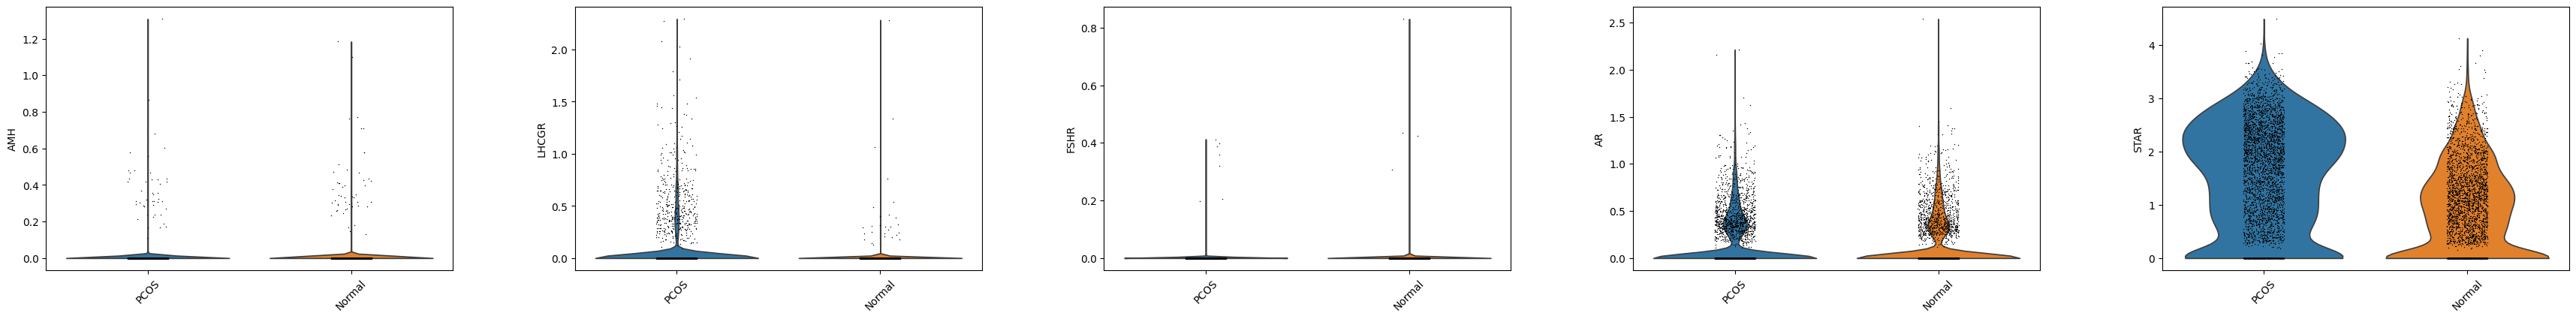

In [4]:
# Fix duplicate cell names
adata.obs_names_make_unique()

# Now plot expression of our target biomarker genes
# comparing PCOS vs Normal
sc.pl.violin(adata, 
             keys=['AMH', 'LHCGR', 'FSHR', 'AR', 'STAR'],
             groupby='condition',
             rotation=45,
             save='_biomarkers_pcos_vs_normal.png')

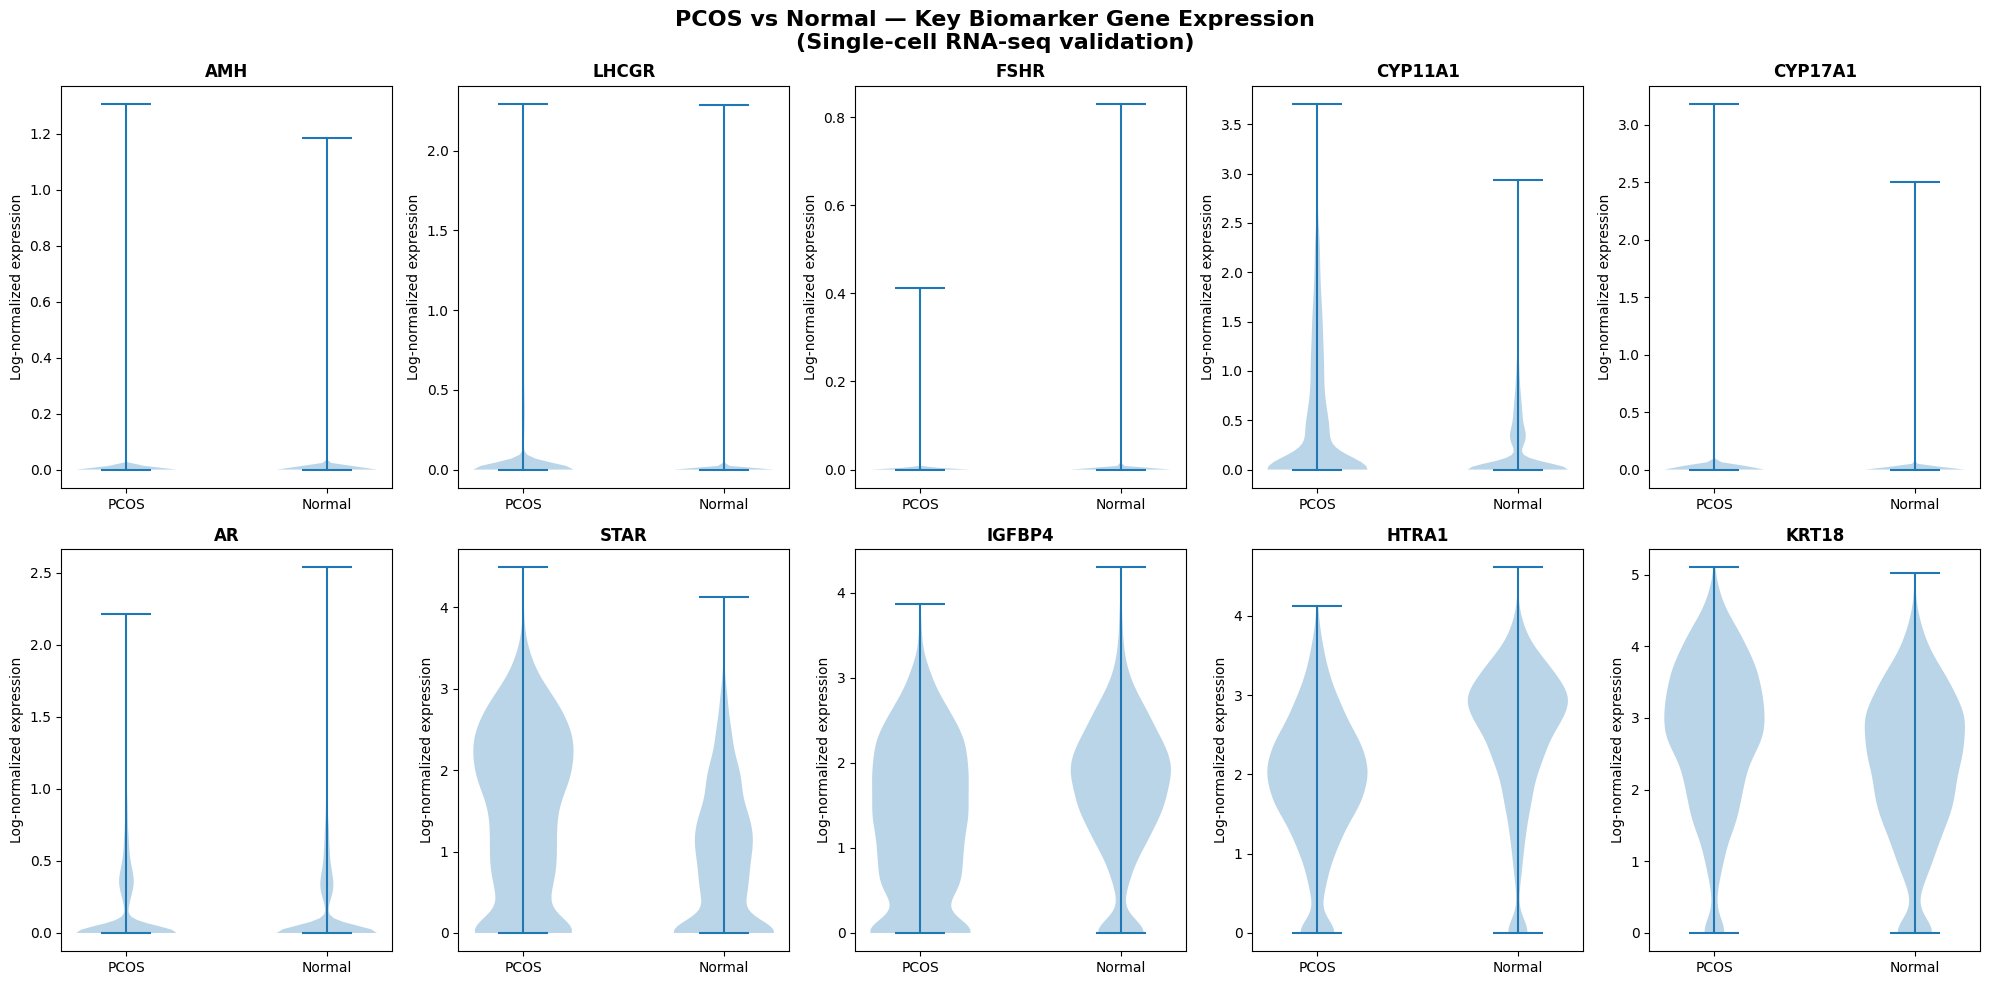

Saved!


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
genes = ['AMH', 'LHCGR', 'FSHR', 'CYP11A1', 'CYP17A1', 'AR', 'STAR', 'IGFBP4', 'HTRA1', 'KRT18']

for idx, gene in enumerate(genes):
    row = idx // 5
    col = idx % 5
    ax = axes[row, col]
    
    pcos_expr = adata[adata.obs['condition'] == 'PCOS', gene].X.toarray().flatten()
    normal_expr = adata[adata.obs['condition'] == 'Normal', gene].X.toarray().flatten()
    
    ax.violinplot([pcos_expr, normal_expr], positions=[0, 1])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['PCOS', 'Normal'])
    ax.set_title(gene, fontweight='bold', fontsize=12)
    ax.set_ylabel('Log-normalized expression')

plt.suptitle('PCOS vs Normal — Key Biomarker Gene Expression\n(Single-cell RNA-seq validation)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('biomarker_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [6]:
from scipy import stats
import pandas as pd

genes = ['AMH', 'LHCGR', 'FSHR', 'CYP11A1', 'CYP17A1', 'AR', 'STAR', 'IGFBP4', 'HTRA1', 'KRT18']

results = []
for gene in genes:
    pcos_expr = adata[adata.obs['condition'] == 'PCOS', gene].X.toarray().flatten()
    normal_expr = adata[adata.obs['condition'] == 'Normal', gene].X.toarray().flatten()
    
    stat, pval = stats.mannwhitneyu(pcos_expr, normal_expr, alternative='two-sided')
    
    pcos_mean = pcos_expr.mean()
    normal_mean = normal_expr.mean()
    fold_change = pcos_mean - normal_mean  # log scale so subtraction = fold change
    
    results.append({
        'Gene': gene,
        'PCOS_mean': round(pcos_mean, 4),
        'Normal_mean': round(normal_mean, 4),
        'Log_FC': round(fold_change, 4),
        'Direction': '↑ PCOS' if fold_change > 0 else '↓ PCOS',
        'p_value': round(pval, 6),
        'Significant': '✅' if pval < 0.05 else '❌'
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

   Gene  PCOS_mean  Normal_mean  Log_FC Direction  p_value Significant
    AMH     0.0047       0.0059 -0.0012    ↓ PCOS 0.401664           ❌
  LHCGR     0.0628       0.0036  0.0592    ↑ PCOS 0.000000           ✅
   FSHR     0.0006       0.0006  0.0000    ↑ PCOS 0.446354           ❌
CYP11A1     0.4832       0.1919  0.2913    ↑ PCOS 0.000000           ✅
CYP17A1     0.0294       0.0120  0.0174    ↑ PCOS 0.000000           ✅
     AR     0.1516       0.1442  0.0075    ↑ PCOS 0.088194           ❌
   STAR     1.5212       0.9410  0.5802    ↑ PCOS 0.000000           ✅
 IGFBP4     1.3401       1.6734 -0.3333    ↓ PCOS 0.000000           ✅
  HTRA1     1.8903       2.4931 -0.6027    ↓ PCOS 0.000000           ✅
  KRT18     2.7762       2.3306  0.4456    ↑ PCOS 0.000000           ✅


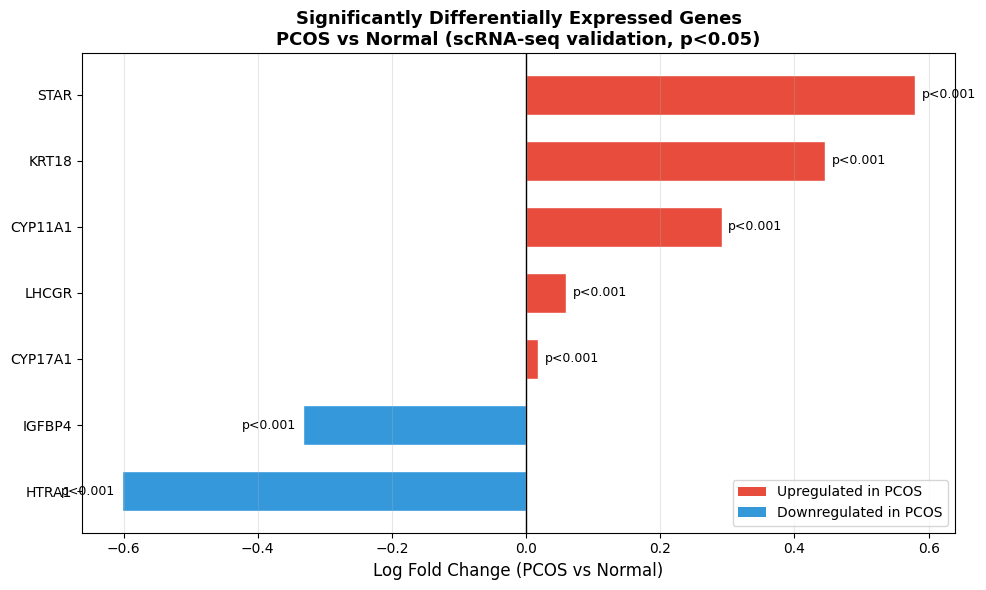

Saved!


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Only significant genes
sig_genes = df_results[df_results['Significant'] == '✅'].copy()
sig_genes = sig_genes.sort_values('Log_FC', ascending=True)

colors = ['#e74c3c' if fc > 0 else '#3498db' for fc in sig_genes['Log_FC']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sig_genes['Gene'], sig_genes['Log_FC'], color=colors, edgecolor='white', height=0.6)

ax.axvline(x=0, color='black', linewidth=1, linestyle='-')
ax.set_xlabel('Log Fold Change (PCOS vs Normal)', fontsize=12)
ax.set_title('Significantly Differentially Expressed Genes\nPCOS vs Normal (scRNA-seq validation, p<0.05)', 
             fontsize=13, fontweight='bold')

# Add p-value annotations
for i, (_, row) in enumerate(sig_genes.iterrows()):
    ax.text(row['Log_FC'] + (0.01 if row['Log_FC'] > 0 else -0.01), 
            i, f"p<0.001", va='center', 
            ha='left' if row['Log_FC'] > 0 else 'right', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Upregulated in PCOS'),
                   Patch(facecolor='#3498db', label='Downregulated in PCOS')]
ax.legend(handles=legend_elements, loc='lower right')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('scrnaseq_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [8]:
import shutil
shutil.copy('scrnaseq_validation.png', 
'/Users/jacob1/SBS-Hackathon-Team-27/plots/scrnaseq_validation.png')
print("Copied to project!")


Copied to project!
